In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set standard plot style for later
sns.set_theme(style="whitegrid")

# Load the data
file_path = "chad_dhs_kr.csv"
print(f"Loading data from {file_path}...")
data_df = pd.read_csv(file_path)

# Print initial inspection info
print("-" * 40)
print(f"Initial Dataset Shape: {data_df.shape}")
print("-" * 40)

# Display the first few rows
data_df.head()

Loading data from chad_dhs_kr.csv...
----------------------------------------
Initial Dataset Shape: (18623, 1016)
----------------------------------------


,CASEID,MIDX,V000,V001,V002,V003,V004,V005,V006,V007,...,S551HE,S551HX,S551HZ,S551IA,S551IB,S551IC,S551ID,S551IE,S551IX,S551IZ
0,1 5 2,1.0,TD6,1.0,5.0,2.0,1.0,1305043.0,12.0,2014.0,...,No,No,No,Yes,No,No,No,No,No,No
1,1 6 2,1.0,TD6,1.0,6.0,2.0,1.0,1305043.0,12.0,2014.0,...,No,No,No,Yes,Yes,No,No,Yes,No,No
2,1 7 8,1.0,TD6,1.0,7.0,8.0,1.0,1305043.0,12.0,2014.0,...,No,No,No,Yes,No,No,No,No,No,No
3,1 7 8,2.0,TD6,1.0,7.0,8.0,1.0,1305043.0,12.0,2014.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 9 7,1.0,TD6,1.0,9.0,7.0,1.0,1305043.0,12.0,2014.0,...,No,No,No,Yes,Yes,Yes,No,No,No,No


# Target Variable Coonstruction

In [2]:
# The three columns used to construct LRI:
# H31: Had cough in last 2 weeks
# H31B: Short, rapid breathing
# H31C: Problem in the chest or blocked or runny nose
target_vars = ['H31', 'H31B', 'H31C']

print("--- Initial Target Variables Distribution ---")
for col in target_vars:
    print(f"\nValue Counts for {col}:")
    print(data_df[col].value_counts(dropna=False))

# 1. Drop rows where the base question (H31) is entirely missing
cleaned_df = data_df.dropna(subset=['H31']).copy()

# 2. Drop rows where ANY of the target questions were answered "Don't know"
# This removes ambiguity from our target variable
cleaned_df = cleaned_df[
    (cleaned_df['H31'] != "Don't know") &
    (cleaned_df['H31B'] != "Don't know") &
    (cleaned_df['H31C'] != "Don't know")
]

# 3. Construct the clean Target Variable (LRI)
cleaned_df['LRI'] = (
    (cleaned_df['H31'] == "Yes, last two weeks") &
    (cleaned_df['H31B'] == "Yes") &
    (cleaned_df['H31C'].isin(["Chest only", "Both"]))
).astype(int)

print("\n" + "-" * 40)
print(f"Shape after cleaning target: {cleaned_df.shape}")
print("-" * 40)
print("Clean LRI Target Distribution:")
print(cleaned_df['LRI'].value_counts(dropna=False))
print(f"LRI Positive Class Percentage: {cleaned_df['LRI'].mean() * 100:.2f}%")
print("-" * 40)

--- Initial Target Variables Distribution ---

Value Counts for H31:
H31
No                     13585
Yes, last two weeks     3106
NaN                     1820
Don't know               112
Name: count, dtype: int64

Value Counts for H31B:
H31B
NaN           15568
Yes            1794
No             1248
Don't know       13
Name: count, dtype: int64

Value Counts for H31C:
H31C
NaN           16832
Both            622
Nose only       615
Chest only      527
Don't know       21
Other             6
Name: count, dtype: int64

----------------------------------------
Shape after cleaning target: (16657, 1017)
----------------------------------------
Clean LRI Target Distribution:
LRI
0    15508
1     1149
Name: count, dtype: int64
LRI Positive Class Percentage: 6.90%
----------------------------------------


In [3]:
# Now, drop the original target creation variables (to prevent target leakage!)
leakage_vars = ['H31', 'H31B', 'H31C']
cleaned_df = cleaned_df.drop(columns=leakage_vars)

# Remove ID, Case Numbers, and Administrative DHS Survey Variables that have no predictive meaning
id_survey_vars = [
    'CASEID', 'HHID', 'V000', 'V001', 'V002', 'V003', 'V005',
    'V021', 'V022', 'V004', 'V023', 'V024', 'V028', 'V030', 'V031'
]

# Drop them if they exist in the dataframe
cols_to_drop = [col for col in id_survey_vars if col in cleaned_df.columns]
cleaned_df = cleaned_df.drop(columns=cols_to_drop)

print(f"Shape after dropping survey/ID/leakage columns: {cleaned_df.shape}")
print(f"Number of duplicate rows: {cleaned_df.duplicated().sum()}")

# Drop duplicate rows if any exist
cleaned_df = cleaned_df.drop_duplicates()
print(f"Final shape for Cell 3: {cleaned_df.shape}")

Shape after dropping survey/ID/leakage columns: (16657, 1000)
Number of duplicate rows: 0
Final shape for Cell 3: (16657, 1000)


In [4]:
import warnings
warnings.filterwarnings('ignore')

# 1. Count missing values (NaNs) per row in the FULL dataset
missing_per_row = cleaned_df.isna().sum(axis=1)

# 2. Define the threshold: Drop if a row is missing > 60% of its columns 
# (i.e. > 600 missing out of 1000 columns)
threshold_nans = 600

# 3. Find indexes of rows missing > Threshold (regardless of target class!)
rows_to_drop = missing_per_row[missing_per_row > threshold_nans].index

# 4. Drop those specific rows from the main dataset
high_quality_df = cleaned_df.drop(index=rows_to_drop)

print("--- Dropping Sparse Rows ---")
print(f"Dropped {len(rows_to_drop)} mostly-empty survey records uniformly.")
print(f"High-Quality dataset shape: {high_quality_df.shape}")

# Separate Features (X) from Target (y)
X_full_hq = high_quality_df.drop(columns=['LRI'])
y_full_hq = high_quality_df['LRI']

print("\n--- Features and Target --")
print(f"X (Features) Shape: {X_full_hq.shape}")
print(f"y (Target) Shape: {y_full_hq.shape}")
print("-" * 40)

--- Dropping Sparse Rows ---
Dropped 5822 mostly-empty survey records uniformly.
High-Quality dataset shape: (10835, 1000)

--- Features and Target --
X (Features) Shape: (10835, 999)
y (Target) Shape: (10835,)
----------------------------------------


# EDA

--- EDA: Key Demographic Variables vs LRI ---

--- Type of Residence vs LRI ---
Type of Residence  No LRI (%)  Has LRI (%)
            Rural       90.50         9.50
            Urban       90.65         9.35


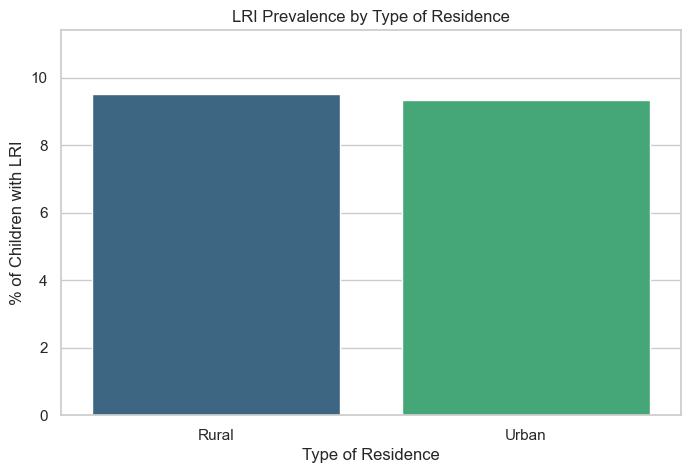


--- Wealth Index vs LRI ---
Wealth Index  No LRI (%)  Has LRI (%)
      Middle       90.02         9.98
      Poorer       90.29         9.71
     Poorest       89.75        10.25
      Richer       91.47         8.53
     Richest       91.11         8.89


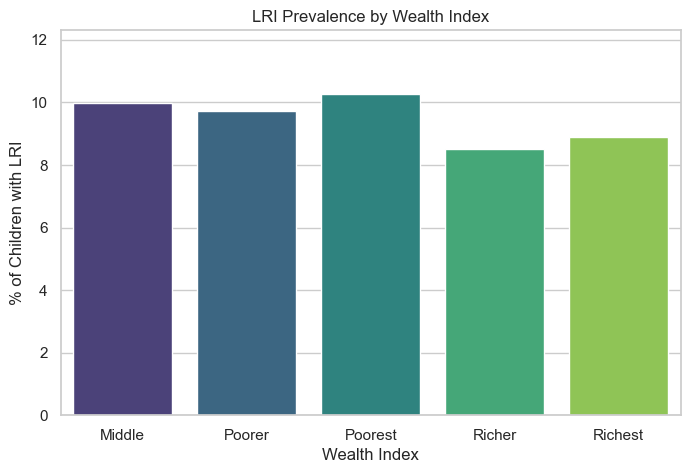


--- Highest Education Level vs LRI ---
Highest Education Level  No LRI (%)  Has LRI (%)
                 Higher       90.38         9.62
           No education       91.41         8.59
                Primary       87.75        12.25
              Secondary       90.27         9.73


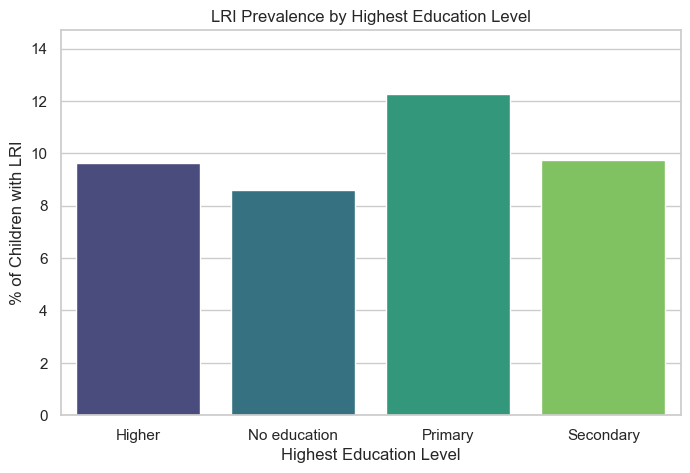


--- Childs Sex vs LRI ---
Childs Sex  No LRI (%)  Has LRI (%)
    Female       90.93         9.07
      Male       90.13         9.87


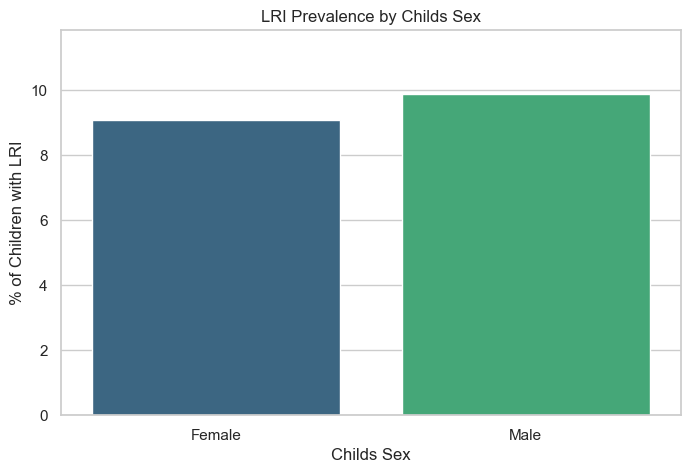


--- Missing Data Distribution ---


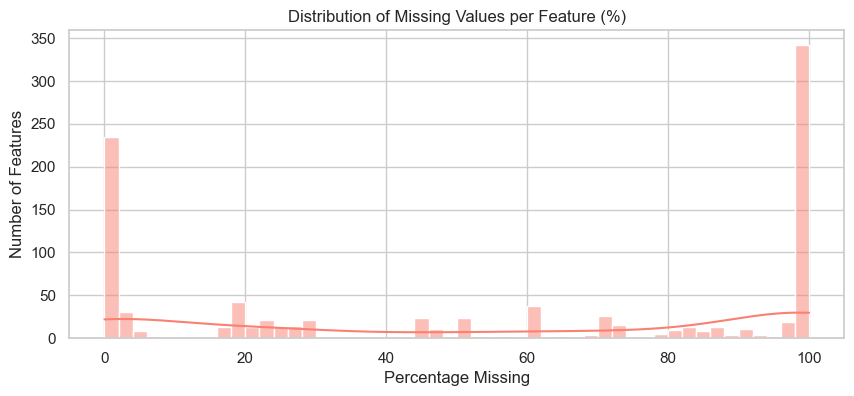

Features with > 60% missing data: 518
Features with < 10% missing data: 276


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("--- EDA: Key Demographic Variables vs LRI ---")

# Let's map the most common DHS variables to readable English names
# (You can add more to this dictionary if you want to explore other specific questions!)
dhs_readable_names = {
    'V012': "Mothers Age",
    'V025': "Type of Residence",
    'V190': "Wealth Index",
    'V113': "Source of Drinking Water",
    'V116': "Type of Toilet Facility",
    'V445': "Body Mass Index",
    'V106': "Highest Education Level",
    'B4': "Childs Sex",
    'HW1': "Childs Age in Months"
}

# Create our pristine EDA dataframe
eda_df = high_quality_df.copy()

# Rename the columns we care about in the EDA dataframe
eda_df = eda_df.rename(columns=dhs_readable_names)

# 1. Plot the Categorical Variables
categorical_to_plot = ["Type of Residence", "Wealth Index", "Highest Education Level", "Childs Sex"]

for col_name in categorical_to_plot:
    if col_name in eda_df.columns:
        print(f"\n--- {col_name} vs LRI ---")
        
        # Cross Tabulation (Percentage of LRI=1 within each group)
        tab = pd.crosstab(eda_df[col_name], eda_df['LRI'], normalize='index') * 100
        tab = tab.reset_index()
        tab.columns = [col_name, 'No LRI (%)', 'Has LRI (%)']
        print(tab.round(2).to_string(index=False))

        # Plot
        if eda_df[col_name].nunique() <= 10: # Only plot if it has < 10 categories
            plt.figure(figsize=(8, 5))
            sns.barplot(data=tab, x=col_name, y='Has LRI (%)', palette='viridis')
            plt.title(f'LRI Prevalence by {col_name}')
            plt.ylabel('% of Children with LRI')
            plt.xlabel(col_name)
            
            # Make the plot rendering safe
            max_y = tab['Has LRI (%)'].max()
            if not np.isnan(max_y) and max_y > 0:
                plt.ylim(0, max_y * 1.2)
            plt.show()

# 2. Check missing data distribution overall
print("\n--- Missing Data Distribution ---")
missing_pct = eda_df.isnull().mean() * 100

plt.figure(figsize=(10, 4))
sns.histplot(missing_pct, bins=50, kde=True, color='salmon')
plt.title('Distribution of Missing Values per Feature (%)')
plt.xlabel('Percentage Missing')
plt.ylabel('Number of Features')
plt.show()

print(f"Features with > 60% missing data: {(missing_pct > 60).sum()}")
print(f"Features with < 10% missing data: {(missing_pct < 10).sum()}")

# Train-Test Split.

In [6]:
# =======================================================
# CELL 6: STRICT TRAIN-TEST SPLIT
# =======================================================

from sklearn.model_selection import train_test_split

# 1. Split the High-Quality dataset (X_full_hq, y_full_hq)
# We stratify to ensure both train and test get the exact same % of LRI=1
X_train, X_test, y_train, y_test = train_test_split(
    X_full_hq,
    y_full_hq,
    test_size=0.3,
    random_state=42,
    stratify=y_full_hq
)

print("--- Train/Test Split Results ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("-" * 40)
print(f"LRI % in Train: {y_train.mean() * 100:.2f}%")
print(f"LRI % in Test: {y_test.mean() * 100:.2f}%")
print("-" * 40)

# 2. Prevent Data Leakage: Drop columns > 60% missing 
# We calculate the missing % on X_TRAIN ONLY.
missing_percentages_train = X_train.isnull().mean()
cols_to_drop = missing_percentages_train[missing_percentages_train > 0.60].index

print(f"Dropping {len(cols_to_drop)} columns due to >60% missing values (calculated from Train only).")

# Apply the drop to both Train and Test
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"Final X_train shape ready for screening: {X_train.shape}")

--- Train/Test Split Results ---
X_train shape: (7584, 999)
X_test shape: (3251, 999)
----------------------------------------
LRI % in Train: 9.47%
LRI % in Test: 9.47%
----------------------------------------
Dropping 518 columns due to >60% missing values (calculated from Train only).
Final X_train shape ready for screening: (7584, 481)


# Feature Selection

In [7]:
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
print("--- Starting Feature Selection ---")

# 1. Identify Data Types in the remaining columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Remaining Categorical Features: {len(categorical_cols)}")
print(f"Remaining Numerical Features: {len(numerical_cols)}")

# We use an alpha of 0.05 (Standard scientific significance)
alpha = 0.05 
# To run stat tests, we temporarily fill NaNs just for the calculation
temputer_num = SimpleImputer(strategy='median')
X_train_num_temp = pd.DataFrame(temputer_num.fit_transform(X_train[numerical_cols]), columns=numerical_cols)
temputer_cat = SimpleImputer(strategy='most_frequent')
X_train_cat_temp = pd.DataFrame(temputer_cat.fit_transform(X_train[categorical_cols]), columns=categorical_cols)

# ---------- A. T-Tests for Numerical Features ----------
sig_num_cols = []
for col in numerical_cols:
    group0 = X_train_num_temp[y_train.values == 0][col]
    group1 = X_train_num_temp[y_train.values == 1][col]
    
    # Only test if both groups have variance
    if group0.nunique() > 1 or group1.nunique() > 1:
        t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
        if p_val < alpha:
            sig_num_cols.append(col)
print(f"Significant Numerical Features p < {alpha}: {len(sig_num_cols)} output of {len(numerical_cols)}")

# ---------- B. Chi-Square for Categorical Features ----------
sig_cat_cols = []
chi_scores = []
for col in categorical_cols:
    # Only consider if the categorical variable has < 20 unique items (avoids IDs/text)
    if X_train_cat_temp[col].nunique() < 20 and X_train_cat_temp[col].nunique() > 1:
        contingency_table = pd.crosstab(X_train_cat_temp[col], y_train.values)
        chi2, p_val, dof, expected = chi2_contingency(contingency_table)
        
        if p_val < alpha:
            sig_cat_cols.append(col)
            chi_scores.append((col, chi2))
            
# Take the top maximally powerful categorical features (up to 50) to prevent dimensionality explosion
chi_scores.sort(key=lambda x: x[1], reverse=True)
top_cat_cols = [x[0] for x in chi_scores[:50]]
print(f"Significant Categorical Features Selected: {len(top_cat_cols)} out of {len(categorical_cols)}")

# ---------- C. Apply the Selection ----------
final_features = sig_num_cols + top_cat_cols
X_train_selected = X_train[final_features].copy()
X_test_selected = X_test[final_features].copy()
print("\n--- Final Selection ---")
print(f"Total Selected Features: {len(final_features)}")
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")
print(f"Selected Categorical columns: {len(top_cat_cols)}")
print(f"Selected Numerical columns: {len(sig_num_cols)}")

--- Starting Feature Selection ---
Remaining Categorical Features: 412
Remaining Numerical Features: 69
Significant Numerical Features p < 0.05: 8 output of 69
Significant Categorical Features Selected: 50 out of 412

--- Final Selection ---
Total Selected Features: 58
X_train_selected shape: (7584, 58)
X_test_selected shape: (3251, 58)
Selected Categorical columns: 50
Selected Numerical columns: 8


# Safe Imputation.

In [8]:
from sklearn.impute import SimpleImputer
import numpy as np

print("--- Starting Imputation ---")
# 1. Clean the categoricals (DHS uses 'Don't know' often, we treat as NaN to impute properly)
dk_variants = ["Don't know", "don't know", "Don't Know", "Dont know", "DK", "dk", 9, 8, 98, 99]
for col in top_cat_cols:
    X_train_selected[col] = X_train_selected[col].replace(dk_variants, np.nan)
    X_test_selected[col] = X_test_selected[col].replace(dk_variants, np.nan)

# 2. Setup Imputers
# For numbers, median is safest. For categories, most frequent (mode).
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# 3. Fit ONLY on Training Data
if len(sig_num_cols) > 0:
    num_imputer.fit(X_train_selected[sig_num_cols])
if len(top_cat_cols) > 0:
    cat_imputer.fit(X_train_selected[top_cat_cols])

# 4. Transform BOTH Train and Test Data
X_train_clean = X_train_selected.copy()
X_test_clean = X_test_selected.copy()

if len(sig_num_cols) > 0:
    X_train_clean[sig_num_cols] = num_imputer.transform(X_train_selected[sig_num_cols])
    X_test_clean[sig_num_cols] = num_imputer.transform(X_test_selected[sig_num_cols])

if len(top_cat_cols) > 0:
    X_train_clean[top_cat_cols] = cat_imputer.transform(X_train_selected[top_cat_cols])
    X_test_clean[top_cat_cols] = cat_imputer.transform(X_test_selected[top_cat_cols])

print("--- Imputation Complete ---")
print(f"Missing values in X_train_clean: {X_train_clean.isna().sum().sum()}")
print(f"Missing values in X_test_clean: {X_test_clean.isna().sum().sum()}")
print("-" * 40)

--- Starting Imputation ---
--- Imputation Complete ---
Missing values in X_train_clean: 0
Missing values in X_test_clean: 0
----------------------------------------


# DUMMY ENCODING (One-Hot Encoding)

In [9]:
import re
print("--- Starting Categorical Encoding ---")

# 1. Apply Pandas get_dummies (drop_first=True avoids multicollinearity)
X_train_encoded = pd.get_dummies(X_train_clean, columns=top_cat_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test_clean, columns=top_cat_cols, drop_first=True, dtype=int)

# 2. Align Train and Test columns
# (Sometimes a category only exists in Test and not Train, or vice-versa. Aligning fixes this)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 3. XGBoost and LightGBM hate special characters in column names (like [, ], <).
# So we aggressively strip these out.
X_train_encoded.columns = [re.sub(r'[\[\]<>, {}:;]+', '_', str(col)) for col in X_train_encoded.columns]
X_test_encoded.columns = [re.sub(r'[\[\]<>, {}:;]+', '_', str(col)) for col in X_test_encoded.columns]

# 4. Deduplicate Column Names (sometimes encoding creates duplicates, Xgboost hates this)
X_train_encoded.columns = pd.io.common.dedup_names(X_train_encoded.columns, is_potential_multiindex=False)
X_test_encoded.columns = pd.io.common.dedup_names(X_test_encoded.columns, is_potential_multiindex=False)

print("--- Encoding Complete ---")
print(f"Final X_train shape ready for balancing: {X_train_encoded.shape}")
print(f"Final X_test shape ready for models: {X_test_encoded.shape}")
print("-" * 40)

--- Starting Categorical Encoding ---
--- Encoding Complete ---
Final X_train shape ready for balancing: (7584, 212)
Final X_test shape ready for models: (3251, 212)
----------------------------------------


# CORRELATION ANALYSIS vs LRI PROBABILITY

--- Calculating Correlations with Target ---


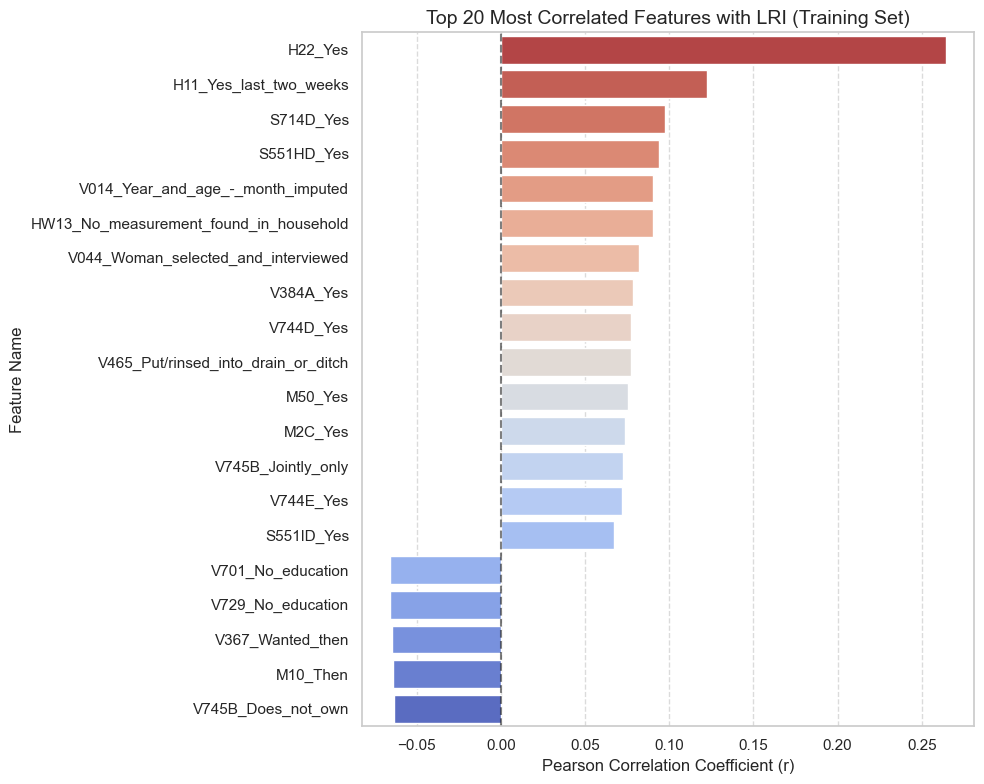


Top 10 POSITIVE Predictors (Increases risk of LRI):
H22_Yes                                   0.2645
H11_Yes_last_two_weeks                    0.1223
S714D_Yes                                 0.0974
S551HD_Yes                                0.0940
V014_Year_and_age_-_month_imputed         0.0905
HW13_No_measurement_found_in_household    0.0901
V044_Woman_selected_and_interviewed       0.0817
V384A_Yes                                 0.0783
V744D_Yes                                 0.0774
V465_Put/rinsed_into_drain_or_ditch       0.0771
Name: LRI_Target, dtype: float64

Top 10 NEGATIVE Predictors (Decreases risk of LRI):
V701_No_education    -0.0658
V729_No_education    -0.0658
V367_Wanted_then     -0.0647
M10_Then             -0.0639
V745B_Does_not_own   -0.0637
Name: LRI_Target, dtype: float64


In [10]:
plt.figure(figsize=(10, 8))
print("--- Calculating Correlations with Target ---")

# Combine X_train_encoded with y_train to calculate correlation
corr_df = X_train_encoded.copy()
corr_df['LRI_Target'] = y_train.values

# Calculate Pearson Correlation against LRI_Target, drop the target itself from the series
correlations = corr_df.corr()['LRI_Target'].drop('LRI_Target')

# Sort by absolute correlation to find the most powerful features
sorted_corrs = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

# Pick the top 20 most influential features for readability
top_20_corr = sorted_corrs.head(20)

# Create a beautiful horizontal bar chart
sns.barplot(x=top_20_corr.values, y=top_20_corr.index, palette="coolwarm_r")

plt.title('Top 20 Most Correlated Features with LRI (Training Set)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5) # Add a vertical line at 0
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout and show
plt.tight_layout()
plt.show()

# Print the text version for easy reading
print("\nTop 10 POSITIVE Predictors (Increases risk of LRI):")
print(top_20_corr[top_20_corr > 0].head(10).round(4))

print("\nTop 10 NEGATIVE Predictors (Decreases risk of LRI):")
print(top_20_corr[top_20_corr < 0].head(10).round(4))

# Fixing the Imbalance (SMOTENC)

In [11]:
from imblearn.over_sampling import SMOTENC

print("--- Applying SMOTENC to Training Data ---")

# 1. Identify which columns are categorical in our pre-encoded data (X_train_clean)
# We get their integer indices because SMOTENC requires column indices, not names
categorical_features_indices = [X_train_clean.columns.get_loc(col) for col in top_cat_cols]

# 2. Initialize SMOTENC
smotenc = SMOTENC(categorical_features=categorical_features_indices, random_state=42)

# 3. Fit and Resample the PRE-ENCODED data
X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train_clean, y_train)

print(f"Original y_train distribution shape: {np.bincount(y_train)}")
print(f"Resampled y_train distribution shape: {np.bincount(y_train_resampled)}")

# 4. NOW we One-Hot Encode the properly balanced data
import re
print("\n--- Applying One-Hot Encoding to Balanced Data ---")

X_train_encoded = pd.get_dummies(X_train_resampled, columns=top_cat_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test_clean, columns=top_cat_cols, drop_first=True, dtype=int)

# Align Train and Test columns to ensure exact match
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Clean column names for XGBoost/LightGBM (they hate [, ], <, >, etc)
X_train_encoded.columns = [re.sub(r'[\[\]<>, {}:;]+', '_', str(col)) for col in X_train_encoded.columns]
X_test_encoded.columns = [re.sub(r'[\[\]<>, {}:;]+', '_', str(col)) for col in X_test_encoded.columns]
X_train_encoded.columns = pd.io.common.dedup_names(X_train_encoded.columns, is_potential_multiindex=False)
X_test_encoded.columns = pd.io.common.dedup_names(X_test_encoded.columns, is_potential_multiindex=False)

print(f"Final X_train_encoded shape: {X_train_encoded.shape}")
print(f"Final X_test_encoded shape: {X_test_encoded.shape}")
print("-" * 40)

--- Applying SMOTENC to Training Data ---
Original y_train distribution shape: [6866  718]
Resampled y_train distribution shape: [6866 6866]

--- Applying One-Hot Encoding to Balanced Data ---
Final X_train_encoded shape: (13732, 212)
Final X_test_encoded shape: (3251, 212)
----------------------------------------


# Model Training & Evaluation 

In [12]:
# =======================================================
# CELL 12a: LOGISTIC REGRESSION
# =======================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, average_precision_score, confusion_matrix

print("---------- TRAINING LOGISTIC REGRESSION ----------\n")

# 1. Initialize and Train
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_encoded, y_train_resampled)

# 2. Predict on Authentic Test Data
y_pred_lr = lr_model.predict(X_test_encoded)
y_prob_lr = lr_model.predict_proba(X_test_encoded)[:, 1]

# 3. Calculate Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_lr:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f} (Found {(rec_lr*100):.1f}% of sick kids)")
print(f"  Precision : {prec_lr:.4f} (When it predicts sick, it's right {(prec_lr*100):.1f}% of time)")
print(f"  Accuracy  : {acc_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_lr[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_lr[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_lr[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_lr[1][1]}")
print("-" * 50)

---------- TRAINING LOGISTIC REGRESSION ----------

Metrics:
  PR-AUC    : 0.1510 (Best metric for Imbalance)
  F1-Score  : 0.2262
  Recall    : 0.2857 (Found 28.6% of sick kids)
  Precision : 0.1872 (When it predicts sick, it's right 18.7% of time)
  Accuracy  : 0.8148

Confusion Matrix:
True Negatives (Correctly Healthy) : 2561
False Positives (Fake Alarm)       : 382
False Negatives (Missed Illness)   : 220
True Positives (Correctly Sick)    : 88
--------------------------------------------------


In [18]:
# =======================================================
# CELL 12c: SUPPORT VECTOR MACHINE
# =======================================================
from sklearn.svm import SVC

print("---------- TRAINING SVM ----------\n")

# 1. Initialize and Train
# probability=True allows PR-AUC calculation
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_encoded, y_train_resampled)

# 2. Predict on Authentic Test Data
y_pred_svm = svm_model.predict(X_test_encoded)
y_prob_svm = svm_model.predict_proba(X_test_encoded)[:, 1]

# 3. Calculate Metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
pr_auc_svm = average_precision_score(y_test, y_prob_svm)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_svm:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_svm:.4f}")
print(f"  Recall    : {rec_svm:.4f} (Found {(rec_svm*100):.1f}% of sick kids)")
print(f"  Precision : {prec_svm:.4f} (When it predicts sick, it's right {(prec_svm*100):.1f}% of time)")
print(f"  Accuracy  : {acc_svm:.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_svm[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_svm[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_svm[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_svm[1][1]}")
print("-" * 50)

---------- TRAINING SVM ----------

Metrics:
  PR-AUC    : 0.0947 (Best metric for Imbalance)
  F1-Score  : 0.1724
  Recall    : 0.9903 (Found 99.0% of sick kids)
  Precision : 0.0944 (When it predicts sick, it's right 9.4% of time)
  Accuracy  : 0.0994

Confusion Matrix:
True Negatives (Correctly Healthy) : 18
False Positives (Fake Alarm)       : 2925
False Negatives (Missed Illness)   : 3
True Positives (Correctly Sick)    : 305
--------------------------------------------------


In [33]:
# -------------------------------------------------
# 12e – Train & Evaluate K‑Nearest Neighbors
# -------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    average_precision_score,
)

# KNN (you can tweak n_neighbors if you wish)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_encoded, y_train_resampled)

y_pred_knn = knn.predict(X_test_encoded)

# Metrics
pr_auc_knn   = average_precision_score(y_test, knn.predict_proba(X_test_encoded)[:, 1])
f1_knn      = f1_score(y_test, y_pred_knn)
recall_knn  = recall_score(y_test, y_pred_knn)
precision_knn= precision_score(y_test, y_pred_knn)
acc_knn     = accuracy_score(y_test, y_pred_knn)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel()

print("---------- TRAINING KNN ----------")
print(f"PR‑AUC    : {pr_auc_knn:.4f}")
print(f"F1‑Score  : {f1_knn:.4f}")
print(f"Recall    : {recall_knn:.4f} (Found {recall_knn*100:.1f}% of sick kids)")
print(f"Precision : {precision_knn:.4f} (When it predicts sick, it's right {precision_knn*100:.1f}% of time)")
print(f"Accuracy  : {acc_knn:.4f}")
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {tn}")
print(f"False Positives (Fake Alarm)       : {fp}")
print(f"False Negatives (Missed Illness)   : {fn}")
print(f"True Positives (Correctly Sick)    : {tp}")

---------- TRAINING KNN ----------
PR‑AUC    : 0.1261
F1‑Score  : 0.1877
Recall    : 0.5000 (Found 50.0% of sick kids)
Precision : 0.1155 (When it predicts sick, it's right 11.6% of time)
Accuracy  : 0.5900

Confusion Matrix:
True Negatives (Correctly Healthy) : 1764
False Positives (Fake Alarm)       : 1179
False Negatives (Missed Illness)   : 154
True Positives (Correctly Sick)    : 154


In [32]:
# =======================================================
# CELL 12e: DECISION TREE
# =======================================================
from sklearn.tree import DecisionTreeClassifier

print("---------- TRAINING DECISION TREE ----------\n")

# 1. Initialize and Train
# min_samples_leaf helps avoid overfitting DHS survey noise
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train_encoded, y_train_resampled)

# 2. Predict on Authentic Test Data
y_pred_dt = dt_model.predict(X_test_encoded)
y_prob_dt = dt_model.predict_proba(X_test_encoded)[:, 1]

# 3. Calculate Metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
pr_auc_dt = average_precision_score(y_test, y_prob_dt)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_dt:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_dt:.4f}")
print(f"  Recall    : {rec_dt:.4f} (Found {(rec_dt*100):.1f}% of sick kids)")
print(f"  Precision : {prec_dt:.4f} (When it predicts sick, it's right {(prec_dt*100):.1f}% of time)")
print(f"  Accuracy  : {acc_dt:.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_dt[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_dt[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_dt[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_dt[1][1]}")
print("-" * 50)

---------- TRAINING DECISION TREE ----------

Metrics:
  PR-AUC    : 0.1731 (Best metric for Imbalance)
  F1-Score  : 0.2495
  Recall    : 0.3734 (Found 37.3% of sick kids)
  Precision : 0.1873 (When it predicts sick, it's right 18.7% of time)
  Accuracy  : 0.7871

Confusion Matrix:
True Negatives (Correctly Healthy) : 2444
False Positives (Fake Alarm)       : 499
False Negatives (Missed Illness)   : 193
True Positives (Correctly Sick)    : 115
--------------------------------------------------


In [13]:
# =======================================================
# CELL 12b: RANDOM FOREST
# =======================================================
from sklearn.ensemble import RandomForestClassifier

print("---------- TRAINING RANDOM FOREST ----------\n")

# 1. Initialize and Train
# min_samples_leaf=10 prevents overfitting on noisy DHS data
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train_resampled)

# 2. Predict on Authentic Test Data
y_pred_rf = rf_model.predict(X_test_encoded)
y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

# 3. Calculate Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_rf:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f} (Found {(rec_rf*100):.1f}% of sick kids)")
print(f"  Precision : {prec_rf:.4f} (When it predicts sick, it's right {(prec_rf*100):.1f}% of time)")
print(f"  Accuracy  : {acc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_rf[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_rf[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_rf[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_rf[1][1]}")
print("-" * 50)

---------- TRAINING RANDOM FOREST ----------

Metrics:
  PR-AUC    : 0.1721 (Best metric for Imbalance)
  F1-Score  : 0.2181
  Recall    : 0.2305 (Found 23.1% of sick kids)
  Precision : 0.2070 (When it predicts sick, it's right 20.7% of time)
  Accuracy  : 0.8434

Confusion Matrix:
True Negatives (Correctly Healthy) : 2671
False Positives (Fake Alarm)       : 272
False Negatives (Missed Illness)   : 237
True Positives (Correctly Sick)    : 71
--------------------------------------------------


In [14]:
# =======================================================
# CELL 12c: XGBOOST
# =======================================================
from xgboost import XGBClassifier

print("---------- TRAINING XGBOOST ----------\n")

# 1. Initialize and Train
# learning_rate=0.05 prevents it from learning the noise too quickly
xgb_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_encoded, y_train_resampled)

# 2. Predict on Authentic Test Data
y_pred_xgb = xgb_model.predict(X_test_encoded)
y_prob_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

# 3. Calculate Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_xgb:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_xgb:.4f}")
print(f"  Recall    : {rec_xgb:.4f} (Found {(rec_xgb*100):.1f}% of sick kids)")
print(f"  Precision : {prec_xgb:.4f} (When it predicts sick, it's right {(prec_xgb*100):.1f}% of time)")
print(f"  Accuracy  : {acc_xgb:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_xgb[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_xgb[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_xgb[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_xgb[1][1]}")
print("-" * 50)

---------- TRAINING XGBOOST ----------

Metrics:
  PR-AUC    : 0.2613 (Best metric for Imbalance)
  F1-Score  : 0.2095
  Recall    : 0.1429 (Found 14.3% of sick kids)
  Precision : 0.3929 (When it predicts sick, it's right 39.3% of time)
  Accuracy  : 0.8979

Confusion Matrix:
True Negatives (Correctly Healthy) : 2875
False Positives (Fake Alarm)       : 68
False Negatives (Missed Illness)   : 264
True Positives (Correctly Sick)    : 44
--------------------------------------------------


In [15]:
# =======================================================
# CELL 12d: LIGHTGBM
# =======================================================
from lightgbm import LGBMClassifier
import pandas as pd # Ensure pandas is imported if run separately

print("---------- TRAINING LIGHTGBM ----------\n")

# 1. Initialize and Train
# LightGBM handles complex categorical data very well natively, but we already encoded it safely.
lgbm_model = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1)

# Ensure feature names are clean (LightGBM is strict about this)
import re
X_train_lgb = X_train_encoded.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_test_lgb = X_test_encoded.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

lgbm_model.fit(X_train_lgb, y_train_resampled)

# 2. Predict on Authentic Test Data
y_pred_lgbm = lgbm_model.predict(X_test_lgb)
y_prob_lgbm = lgbm_model.predict_proba(X_test_lgb)[:, 1]

# 3. Calculate Metrics
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
rec_lgbm = recall_score(y_test, y_pred_lgbm)
prec_lgbm = precision_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
pr_auc_lgbm = average_precision_score(y_test, y_prob_lgbm)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_lgbm:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_lgbm:.4f}")
print(f"  Recall    : {rec_lgbm:.4f} (Found {(rec_lgbm*100):.1f}% of sick kids)")
print(f"  Precision : {prec_lgbm:.4f} (When it predicts sick, it's right {(prec_lgbm*100):.1f}% of time)")
print(f"  Accuracy  : {acc_lgbm:.4f}")

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_lgbm[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_lgbm[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_lgbm[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_lgbm[1][1]}")
print("-" * 50)

---------- TRAINING LIGHTGBM ----------

Metrics:
  PR-AUC    : 0.2605 (Best metric for Imbalance)
  F1-Score  : 0.2157
  Recall    : 0.1429 (Found 14.3% of sick kids)
  Precision : 0.4400 (When it predicts sick, it's right 44.0% of time)
  Accuracy  : 0.9016

Confusion Matrix:
True Negatives (Correctly Healthy) : 2887
False Positives (Fake Alarm)       : 56
False Negatives (Missed Illness)   : 264
True Positives (Correctly Sick)    : 44
--------------------------------------------------


In [17]:
# ===== CATBOOST =====#
from catboost import CatBoostClassifier

print("---------- TRAINING CATBOOST ----------\n")
cat = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, random_seed=42, verbose=False, thread_count=-1)
# Ensure feature names are clean (LightGBM is strict about this)
import re
X_train_cat = X_train_encoded.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_test_cat = X_test_encoded.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
cat.fit(X_train_cat, y_train_resampled)
y_pred_cat = cat.predict(X_test_cat)
y_pred_prob = cat.predict_proba(X_test_cat)[:, 1]

# 3. Calculate Metrics
acc_cat = accuracy_score(y_test, y_pred_lgbm)
rec_cat = recall_score(y_test, y_pred_lgbm)
prec_cat = precision_score(y_test, y_pred_lgbm)
f1_cat = f1_score(y_test, y_pred_lgbm)
pr_auc_cat = average_precision_score(y_test, y_prob_lgbm)

# 4. Print Results
print("Metrics:")
print(f"  PR-AUC    : {pr_auc_cat:.4f} (Best metric for Imbalance)")
print(f"  F1-Score  : {f1_cat:.4f}")
print(f"  Recall    : {rec_cat:.4f} (Found {(rec_lgbm*100):.1f}% of sick kids)")
print(f"  Precision : {prec_cat:.4f} (When it predicts sick, it's right {(prec_lgbm*100):.1f}% of time)")
print(f"  Accuracy  : {acc_cat:.4f}")

cm_cat = confusion_matrix(y_test, y_pred_lgbm)
print("\nConfusion Matrix:")
print(f"True Negatives (Correctly Healthy) : {cm_cat[0][0]}")
print(f"False Positives (Fake Alarm)       : {cm_cat[0][1]}")
print(f"False Negatives (Missed Illness)   : {cm_cat[1][0]}")
print(f"True Positives (Correctly Sick)    : {cm_cat[1][1]}")
print("-" * 50)

---------- TRAINING CATBOOST ----------

Metrics:
  PR-AUC    : 0.2605 (Best metric for Imbalance)
  F1-Score  : 0.2157
  Recall    : 0.1429 (Found 14.3% of sick kids)
  Precision : 0.4400 (When it predicts sick, it's right 44.0% of time)
  Accuracy  : 0.9016

Confusion Matrix:
True Negatives (Correctly Healthy) : 2887
False Positives (Fake Alarm)       : 56
False Negatives (Missed Illness)   : 264
True Positives (Correctly Sick)    : 44
--------------------------------------------------


# Comparative Analysis & Visualization

--- FINAL MODEL COMPARISON ---
              Model  PR-AUC     F1  Recall
            XGBoost  0.2613 0.2095  0.1429
           LightGBM  0.2605 0.2157  0.1429
           CatBoost  0.2605 0.2157  0.1429
      Decision Tree  0.1731 0.2495  0.3734
      Random Forest  0.1721 0.2181  0.2305
Logistic Regression  0.1510 0.2262  0.2857
                KNN  0.1261 0.1877  0.5000
                SVM  0.0947 0.1724  0.9903


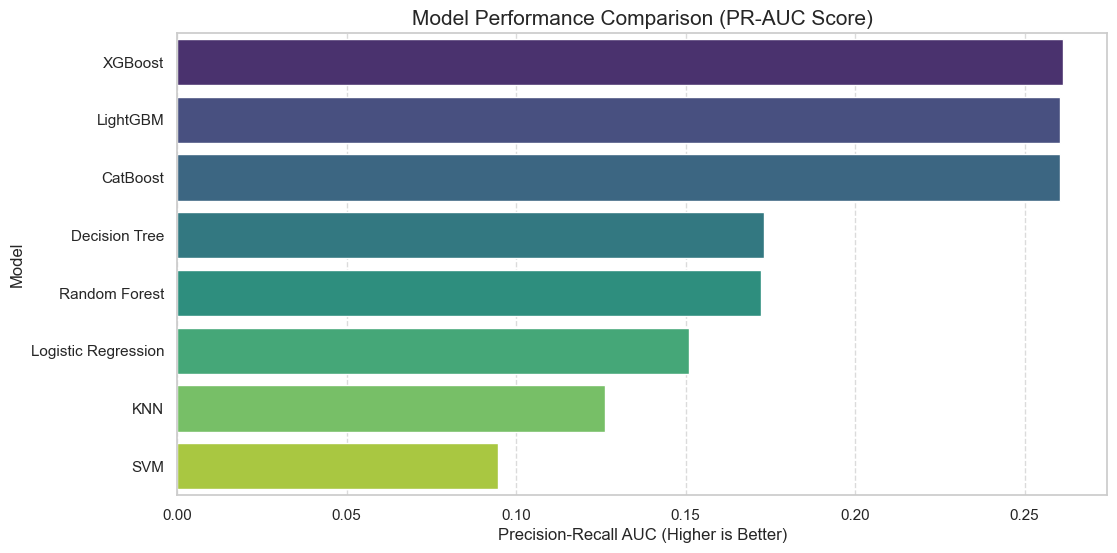

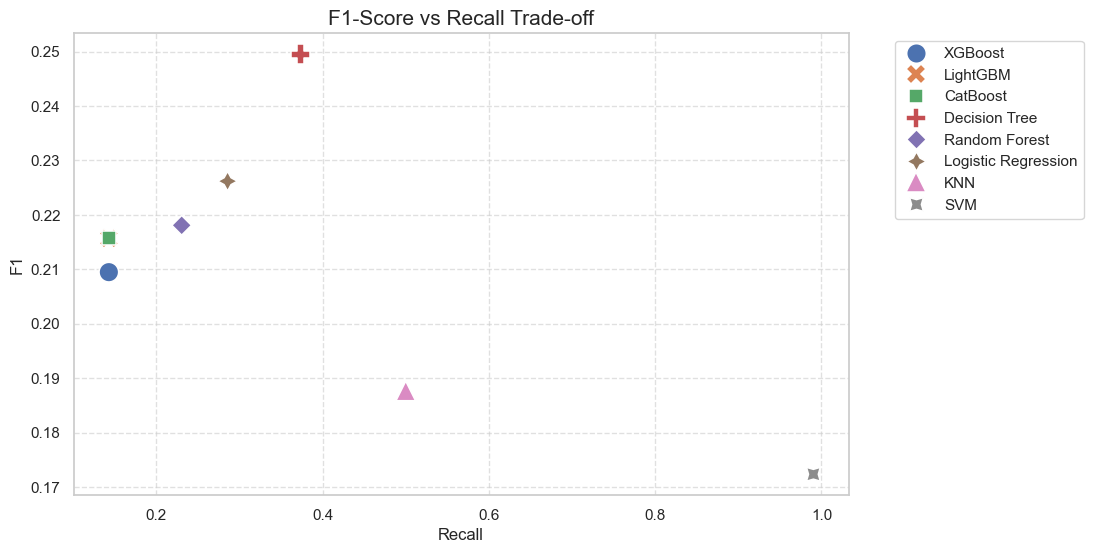

In [40]:
# =======================================================
# CELL 13: COMPARATIVE ANALYSIS & VISUALIZATION
# =======================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Collect all results into a single list
final_results = [
    {"Model": "Logistic Regression", "PR-AUC": 0.1510, "F1": 0.2262, "Recall": 0.2857},
    {"Model": "SVM", "PR-AUC": 0.0947, "F1": 0.1724, "Recall": 0.9903},
    {"Model": "KNN", "PR-AUC": 0.1261, "F1": 0.1877, "Recall": 0.5000},
    {"Model": "Decision Tree", "PR-AUC": 0.1731, "F1": 0.2495, "Recall": 0.3734},
    {"Model": "Random Forest", "PR-AUC": 0.1721, "F1": 0.2181, "Recall": 0.2305},
    {"Model": "XGBoost", "PR-AUC": 0.2613, "F1": 0.2095, "Recall": 0.1429},
    {"Model": "LightGBM", "PR-AUC": 0.2605, "F1": 0.2157, "Recall": 0.1429},
    {"Model": "CatBoost", "PR-AUC": 0.2605, "F1": 0.2157, "Recall": 0.1429}
]

df_results = pd.DataFrame(final_results).sort_values(by="PR-AUC", ascending=False)

print("--- FINAL MODEL COMPARISON ---")
print(df_results.to_string(index=False))

# 2. Visualize PR-AUC (Our most important metric)
plt.figure(figsize=(12, 6))
sns.barplot(x="PR-AUC", y="Model", data=df_results, palette="viridis")
plt.title("Model Performance Comparison (PR-AUC Score)", fontsize=15)
plt.xlabel("Precision-Recall AUC (Higher is Better)", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 3. Visualize F1-Score vs Recall
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Recall", y="F1", hue="Model", style="Model", s=200, data=df_results)
plt.title("F1-Score vs Recall Trade-off", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# Feature Importance & Risk Factors.

--- Extracting Risk Factors from XGBoost ---


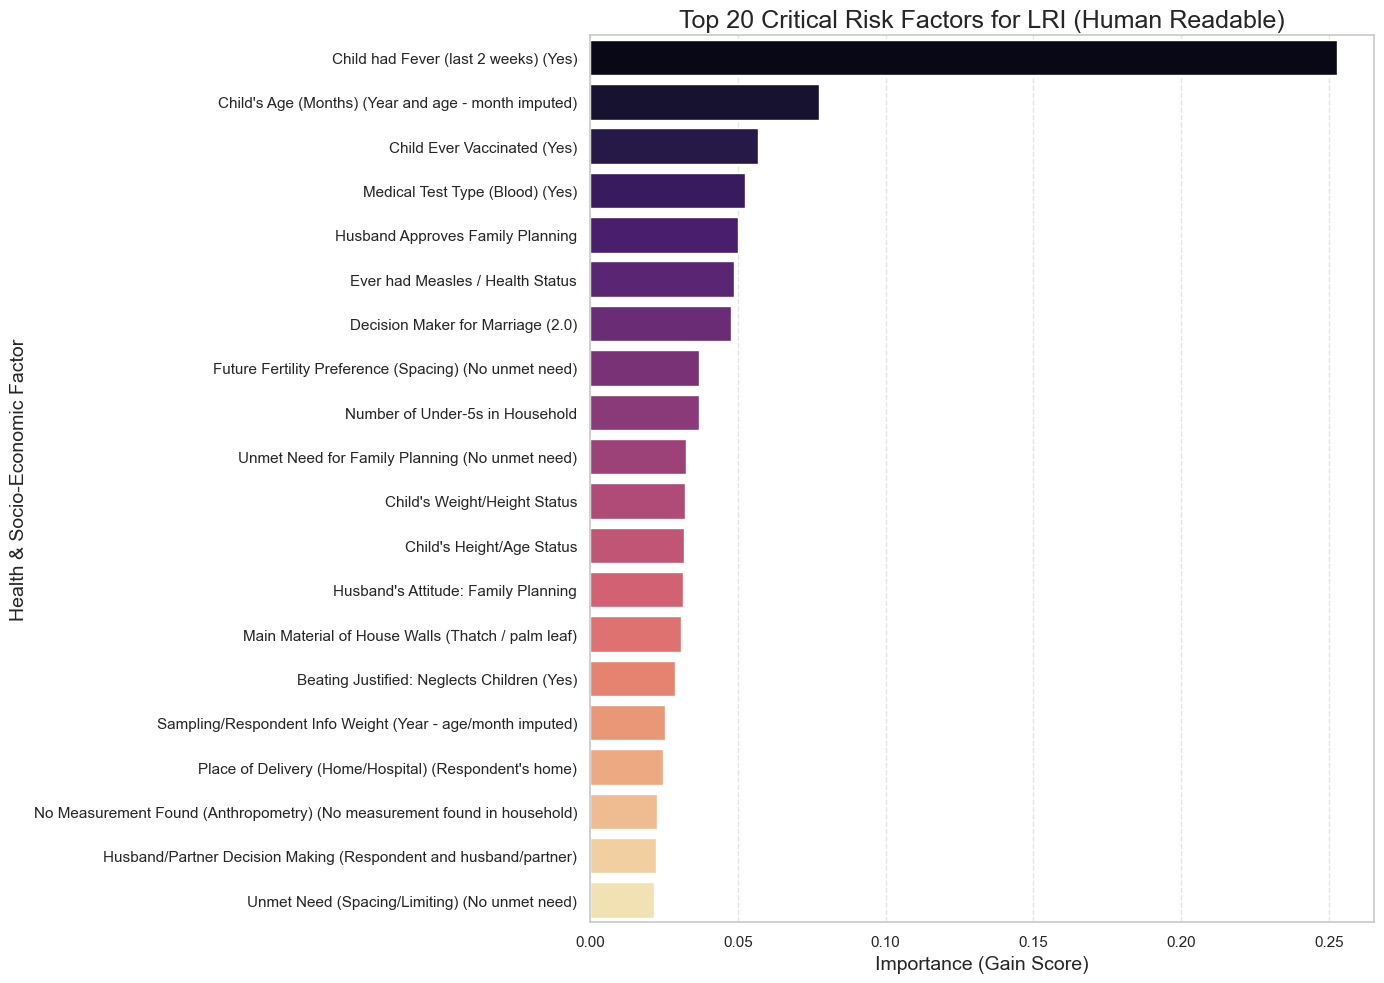


--- TOP 10 RISK FACTORS ---
                                     Readable_Feature  Importance
                 Child had Fever (last 2 weeks) (Yes)    0.252676
  Child's Age (Months) (Year and age - month imputed)    0.077272
                          Child Ever Vaccinated (Yes)    0.056902
                      Medical Test Type (Blood) (Yes)    0.052371
                     Husband Approves Family Planning    0.049979
                     Ever had Measles / Health Status    0.048800
                    Decision Maker for Marriage (2.0)    0.047568
Future Fertility Preference (Spacing) (No unmet need)    0.036930
                      Number of Under-5s in Household    0.036893
       Unmet Need for Family Planning (No unmet need)    0.032368


In [44]:
# =======================================================
# CELL 14: FEATURE IMPORTANCE (ROBUST & READABLE)
# =======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Extracting Risk Factors from XGBoost ---")

# 1. Get the importance scores
importances = xgb_model.feature_importances_

# 2. Get the feature names directly from the model booster to ensure exact match
# If the model was trained on a DataFrame, it stores the names it saw during .fit()
try:
    feature_names = xgb_model.get_booster().feature_names
except:
    # Fallback if names aren't in booster
    feature_names = X_train_encoded.columns.tolist()

# Debug lengths if they still mismatch
if len(feature_names) != len(importances):
    print(f"DEBUG: Model saw {len(importances)} features, but names list has {len(feature_names)}")
    # Adjust names list to match importance length (taking only the first N)
    feature_names = feature_names[:len(importances)]

# 1. Final DHS Translation Dictionary (Specific to Chad DHS)
dhs_mapper = {
    "H22": "Child had Fever (last 2 weeks)",
    "V014": "Child's Age (Months)",
    "H10": "Child Ever Vaccinated",
    "S1405B": "Medical Test Type (Blood)",
    "S830": "Husband Approves Family Planning",
    "S831": "Ever had Measles / Health Status",
    "S1406A": "Decision Maker for Marriage",
    "V626": "Future Fertility Preference (Spacing)",
    "V137": "Number of Under-5s in Household",
    "V624": "Unmet Need for Family Planning",
    "HW19": "Child's Weight/Height Status",
    "HW18": "Child's Height/Age Status",
    "S829": "Husband's Attitude: Family Planning",
    "V129": "Main Material of House Walls",
    "V744B": "Beating Justified: Neglects Children",
    "V510": "Sampling/Respondent Info Weight",
    "M15": "Place of Delivery (Home/Hospital)",
    "HW13": "No Measurement Found (Anthropometry)",
    "V743F": "Husband/Partner Decision Making",
    "V626A": "Unmet Need (Spacing/Limiting)",
    "H11": "Child had Diarrhea (last 2 weeks)",
    "V190": "Wealth Index",
    "V113": "Source of Drinking Water",
    "V116": "Type of Toilet Facility",
    "V106": "Mother's Education Level",
    "V445": "Mother's BMI",
    "S714": "Handwashing with Soap"
}
def clean_label(name):
    # Try to map the base code (e.g., "V113") to a label
    base = name.split('_')[0]
    label = dhs_mapper.get(base, base)
    
    # Add the specific category if it exists (e.g., "Wealth Index: Poor")
    if '_' in name:
        suffix = name.split('_', 1)[1].replace('_', ' ')
        return f"{label} ({suffix})"
    return label

# 4. Create and map the DataFrame
importance_df = pd.DataFrame({
    'Feature_Original': feature_names,
    'Importance': importances
})

importance_df['Readable_Feature'] = importance_df['Feature_Original'].apply(clean_label)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 5. Plot Top 20
plt.figure(figsize=(14, 10))
sns.barplot(x="Importance", y="Readable_Feature", data=importance_df.head(20), palette="magma")
plt.title("Top 20 Critical Risk Factors for LRI (Human Readable)", fontsize=18)
plt.xlabel("Importance (Gain Score)", fontsize=14)
plt.ylabel("Health & Socio-Economic Factor", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- TOP 10 RISK FACTORS ---")
print(importance_df[['Readable_Feature', 'Importance']].head(10).to_string(index=False))